- 姓名: 仇俊塱
- 学号: 24550512006

# 基于机器学习分类算法的心力衰竭预测

- 第一个模型的名字: 逻辑回归
- 第二个模型的名字: 决策树
- (第三个模型的名字: XGBoost)
- (第四个模型的名字: LightGBM)
- (第五个模型的名字: Catboost)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = 'SimHei'
mpl.rcParams['figure.dpi'] = 100
import seaborn as sns
sns.set_style("darkgrid")
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, recall_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV, learning_curve, RandomizedSearchCV
from sklearn.tree import export_graphviz
import graphviz
import scipy.stats as stats
from xgboost import XGBClassifier, plot_tree
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import os
import shap

[数据集超链接](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data)

## 数据导入

In [2]:
# 数据读入
data = pd.read_csv(r'E:\data\data_analysis_learning\homework\datasets\heart.csv')

In [3]:
data.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1


In [4]:
data.shape

(918, 12)

### 对数据集的字段解析

| 字段名 | 中文名称 | 说明 |
| :--- | :--- | :--- |
| **Age** | 年龄 | 患者的年龄 [单位：岁] |
| **Sex** | 性别 | 患者的性别 [M: 男性, F: 女性] |
| **ChestPainType** | 胸痛类型 | 胸痛类型 [TA: 典型心绞痛, ATA: 非典型心绞痛, NAP: 非心源性胸痛, ASY: 无症状] |
| **RestingBP** | 静息血压 | 静息状态下的血压 [单位：毫米汞柱] |
| **Cholesterol** | 胆固醇 | 血清胆固醇水平 [单位：毫米/分升] |
| **FastingBS** | 空腹血糖 | 空腹血糖状态 [1: 空腹血糖 > 120 mg/dl, 0: 否则] |
| **RestingECG** | 静息心电图 | 静息心电图结果 [Normal: 正常, ST: 存在ST-T波异常, LVH: 显示左心室肥厚] |
| **MaxHR** | 最大心率 | 达到的最大心率值 [数值范围: 60-202] |
| **ExerciseAngina** | 运动诱发心绞痛 | 是否出现运动诱发的心绞痛 [Y: 是, N: 否] |
| **Oldpeak** | ST段压低值 | ST段数值压低 [数值，单位：毫米] |
| **ST_Slope** | ST段斜率 | 高峰运动时ST段的斜率 [Up: 上斜型, Flat: 水平型, Down: 下斜型] |
| **HeartDisease** | 心脏病 | `诊断结果 [1: 患有心脏病, 0: 正常] `|

## 数据预处理

### 数值型特征处理

#### 查看是否有缺失值

In [5]:
cols_with_missing = [col for col in data.columns if data[col].isnull().any()]
cols_with_missing

[]

> comments:
- 数据集中没有缺失值

#### 异常值处理

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


> comments:
- RestingBP(静息电压): 最小值为0(人已经死了)，不符合医学逻辑，<mark>明显是异常值。</mark>
- Cholesterol(胆固醇): 正常血清胆固醇水平约120~200 mg/dl，<mark>即使是极低胆固醇，也不可能为 0（胆固醇是人体必需的脂类物质）；</mark>
-  Oldpeak（ST 段压低值）最小值为 - 2.6，<mark>存在异常风险</mark>。医学常识：Oldpeak是运动后 ST 段相对于静息状态的压低程度，正常情况下ST 段压低不会低于 - 1.0 mm（负数值代表 “ST 段抬高”，但抬高的范围通常也不会到 - 2.6 这么极端）；
- `其它特征均在合理范围内。`

In [7]:
data[data['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


<Axes: xlabel='RestingBP', ylabel='Count'>

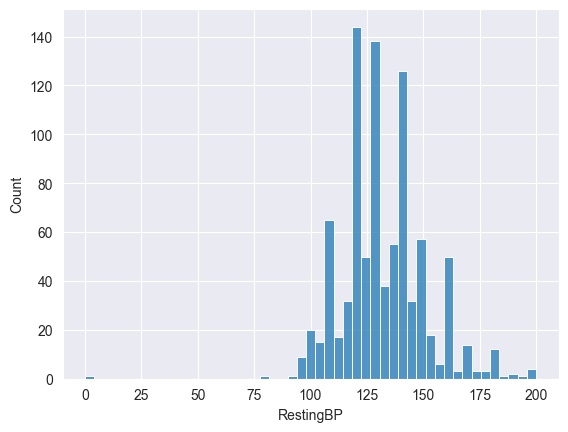

In [8]:
sns.histplot(data=data, x=data['RestingBP'])

> comments:
- 一看到，`最左边只有一个为零`，明显离群，并且其它特征能证明此样本明没有死亡，所以确定为异常值。

In [9]:
# 删除此异常值
data = data[data['RestingBP'] != 0]
data.shape

(917, 12)

In [10]:
data[data['Cholesterol'] == 0].shape

(171, 12)

<Axes: xlabel='Cholesterol', ylabel='Count'>

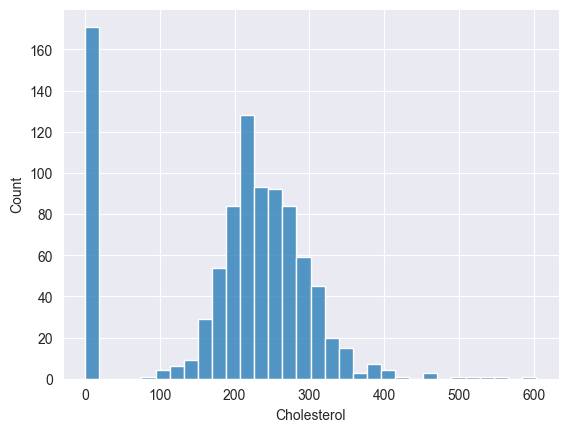

In [11]:
sns.histplot(data=data, x=data['Cholesterol'])

> comments
- 除去Cholesterol=0，其它值的分布基本程正态分布。
- 可见，Cholesterol=0明显为异常值，并且异常值的数量不少，`其实我们可以猜测0是缺失值的填充数`

In [12]:
(len(data[data['Cholesterol'] == 0]) / len(data)) * 100

18.647764449291166

> comments
- 为0的样本数还是挺多的(接近20%)，所以就不像静息电压那样直接删除了。

##### 下面使用`分组中位数填充`对异常数据进行处理

In [13]:
data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [14]:
grouped_result = data.groupby(by=['Sex', 'HeartDisease']).agg(
    中位数=('Cholesterol', 'median')
)
grouped_result

中位数
Sex HeartDisease       
F   0             238.0
    1             253.5
M   0             224.0
    1             214.0

In [15]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [16]:
# data[(data['Sex'] == 'F') & (data['HeartDisease'] == 0) & (data['Cholesterol'] == 0)]['Cholesterol'] = 238.0
# data[(data['Sex'] == 'F') & (data['HeartDisease'] == 1) & (data['Cholesterol'] == 0)]['Cholesterol'] = 253.5
# data[(data['Sex'] == 'M') & (data['HeartDisease'] == 0) & (data['Cholesterol'] == 0)]['Cholesterol'] = 224.0
# data[(data['Sex'] == 'M') & (data['HeartDisease'] == 1) & (data['Cholesterol'] == 0)]['Cholesterol'] = 214.0

In [17]:
data['Cholesterol'] = data['Cholesterol'].replace(0, np.nan)
median_dict = {
    ('F', 0): 238.0,
    ('F', 1): 253.5,
    ('M', 0): 224.0,
    ('M', 1): 214.0
}
data['Cholesterol'] = data.groupby(['Sex', 'HeartDisease'])['Cholesterol'].transform(
    lambda x: x.fillna(median_dict[(x.name[0], x.name[1])])
)

<Axes: xlabel='Cholesterol', ylabel='Count'>

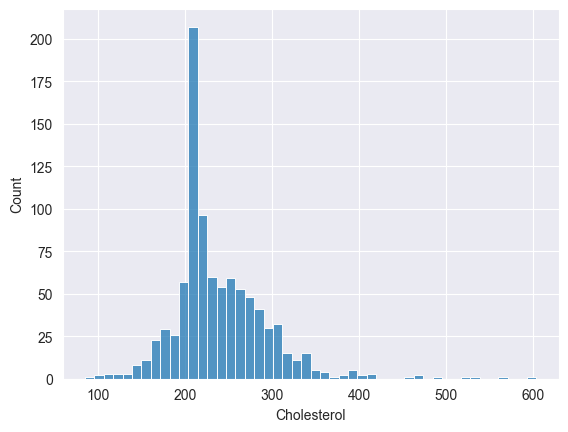

In [18]:
sns.histplot(data=data, x=data['Cholesterol'])

comments:
- 整体胆固醇处于较高水平，但是这符合心脏病患者的临床特征。

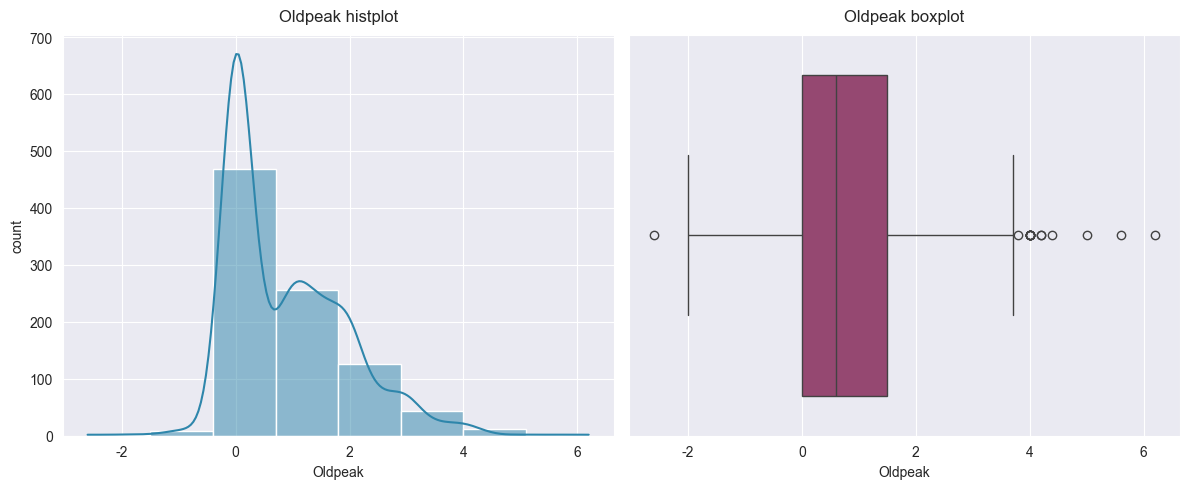

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(
    data=data, 
    x='Oldpeak', 
    bins=8,       
    kde=True,  
    color='#2E86AB',
    ax=ax1     
)
ax1.set_title('Oldpeak histplot', fontsize=12, pad=10)
ax1.set_xlabel('Oldpeak', fontsize=10)
ax1.set_ylabel('count', fontsize=10)
sns.boxplot(
    data=data, 
    x='Oldpeak',
    color='#A23B72',
    ax=ax2       
)
ax2.set_title('Oldpeak boxplot', fontsize=12, pad=10)
ax2.set_xlabel('Oldpeak', fontsize=10)
plt.tight_layout()

> comments:
- 根据临床经验，Oldpeak的值在小于-2，以及大于4都属于极度罕见的情况了，我们认为这些值都属于异常值。
- 下面使用IQR法则将异常值删除。

In [20]:
Q1 = data['Oldpeak'].quantile(0.25)  
Q3 = data['Oldpeak'].quantile(0.75)  
IQR = Q3 - Q1  

lower_bound = Q1 - 1.5 * IQR  # 下边界
upper_bound = Q3 + 1.5 * IQR  # 上边界

# 识别异常值（超出上下边界的行）
outliers = data[(data['Oldpeak'] < lower_bound) | (data['Oldpeak'] > upper_bound)]
(len(outliers) / len(data)) * 100# 异常值数量

1.7448200654307526

> comments:
- 缺失值的占比才占1.74%，可以放心直接删除。

In [21]:
data = data[~((data['Oldpeak'] < lower_bound) | (data['Oldpeak'] > upper_bound))]
data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0


### 字符型特征处理

In [22]:
data.describe(include=['O']).T

,count,unique,top,freq
Sex,901,2,M,711
ChestPainType,901,4,ASY,482
RestingECG,901,3,Normal,546
ExerciseAngina,901,2,N,541
ST_Slope,901,3,Flat,453


> comments:
- 使用独热编码对分类变量进行编码。

In [23]:
data_with_one_hot = pd.get_dummies(data=data, 
            prefix=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], 
            columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

data_with_one_hot.head(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False


In [24]:
data.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1


## EDA

In [25]:
data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0


> comments:
- 标签(离散型): 'HeartDisease'
- 连续型特征: 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'
- 离散型特征: 'FastingBS', 'Sex_F', 'Sex_M', 'ChestPainType_ASY','ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA','RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down','ST_Slope_Flat', 'ST_Slope_Up'

(array([], dtype=float64), [])

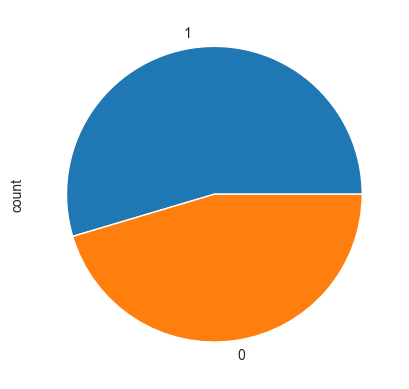

In [26]:
data['HeartDisease'].value_counts().plot(kind='pie')
plt.yticks(rotation=180)

> comments:
- 患病人群与非患病人群的样本数量相差不大。`没有数据有偏的现象。`

### 连续型单特征 vs 标签分析

In [27]:
features_Continuous = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

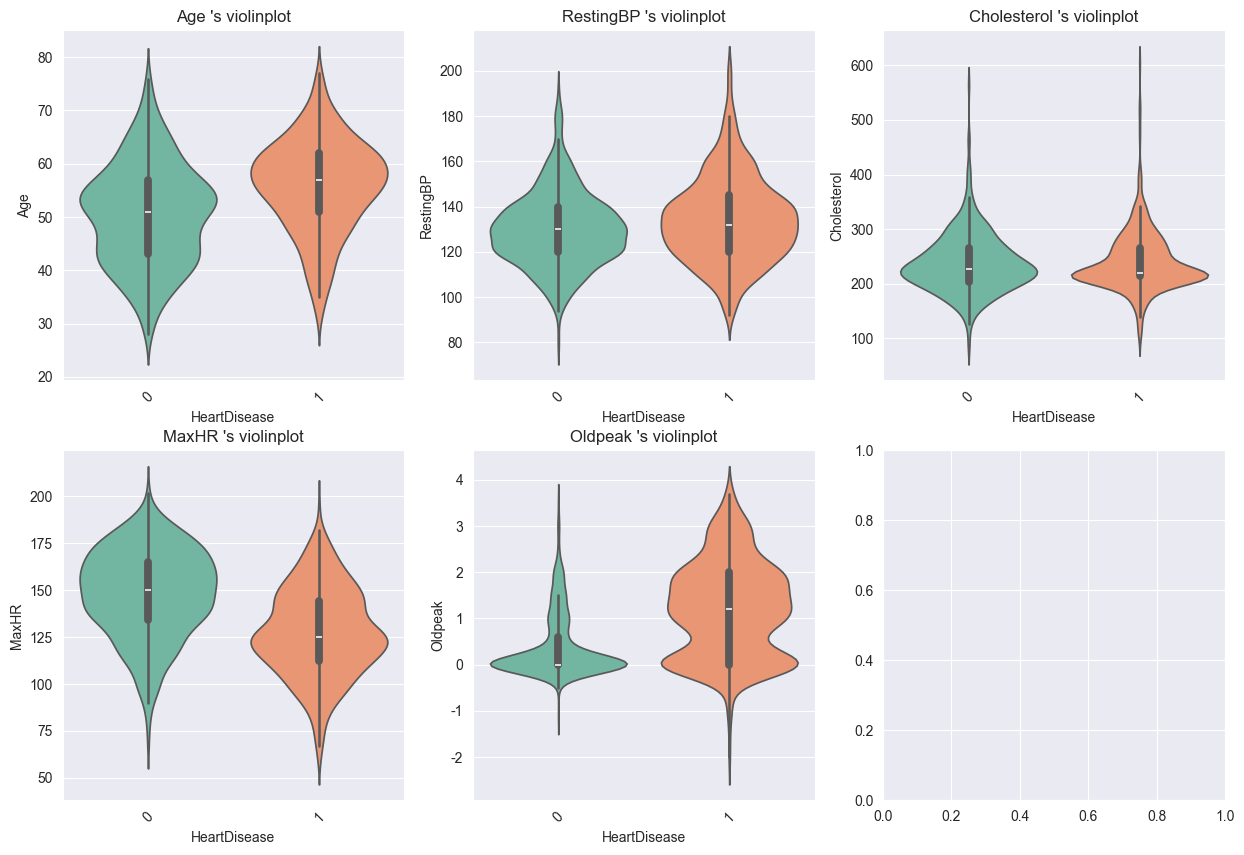

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, feature in enumerate(features_Continuous):
    sns.violinplot(x='HeartDisease', y=feature, data=data, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} \'s violinplot')
    axes[i].tick_params(axis='x', rotation=45)

> comments:
- 年龄: 患有心脏衰竭人群的年龄多集中在`60岁左右`，比不患有心脏衰竭的人群`年龄要更高`，符合生活常识。
- RestingBP: 有无患病的人群基本都集中在130左右。
- Cholesterol: 有无患病的人群基本都集中在220左右。
- RestingBP、Cholesterol: 对应两类别的小提琴图的形状差别不大，`中位数的大小也基本相等。初步判断这两个特征对心脏衰竭的影响不大。`
- MaxHR: 无患病人群重要集中在125-175区间，而患病人群主要集中在125左右，`患病人群的MaxHR普遍会比非患病人群更低。`
- Oldpeak: 非患病人群的Oldpeak主要集中在0附近，但是患病人群主要集中在1附近，`整体数值要比非患病人群要高。`

<Axes: >

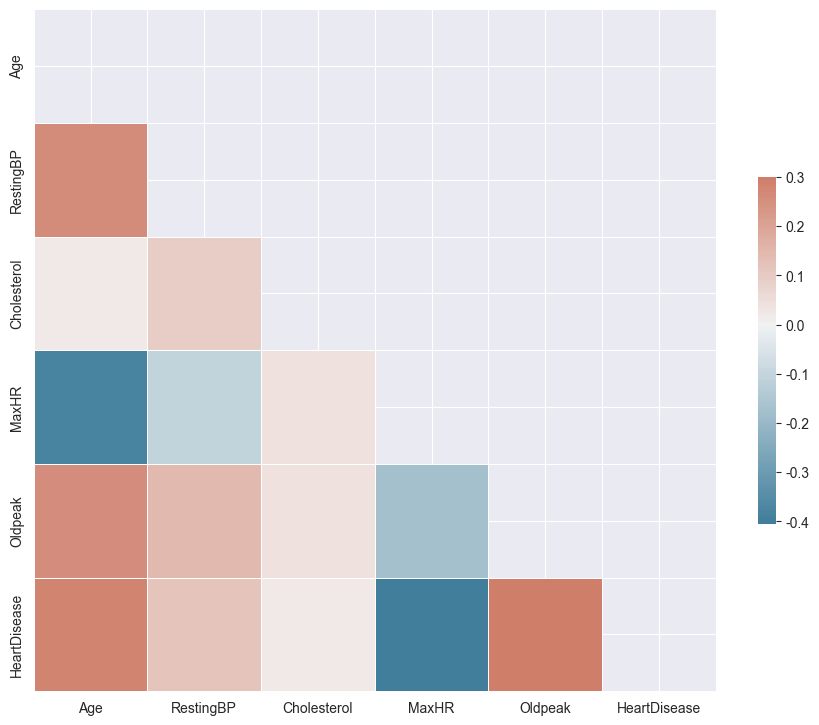

In [29]:
corr_matrix = data[features_Continuous + ['HeartDisease']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

comments:
- 可以看到`RestingBP、Cholesterol与标签的相关系数`都比较低(其实也验证了上面的分析)。
- 后续建模过程中可以考虑删除这两个特征看看是否能提高模型的效果。

### 连续型双特征 vs 标签分析

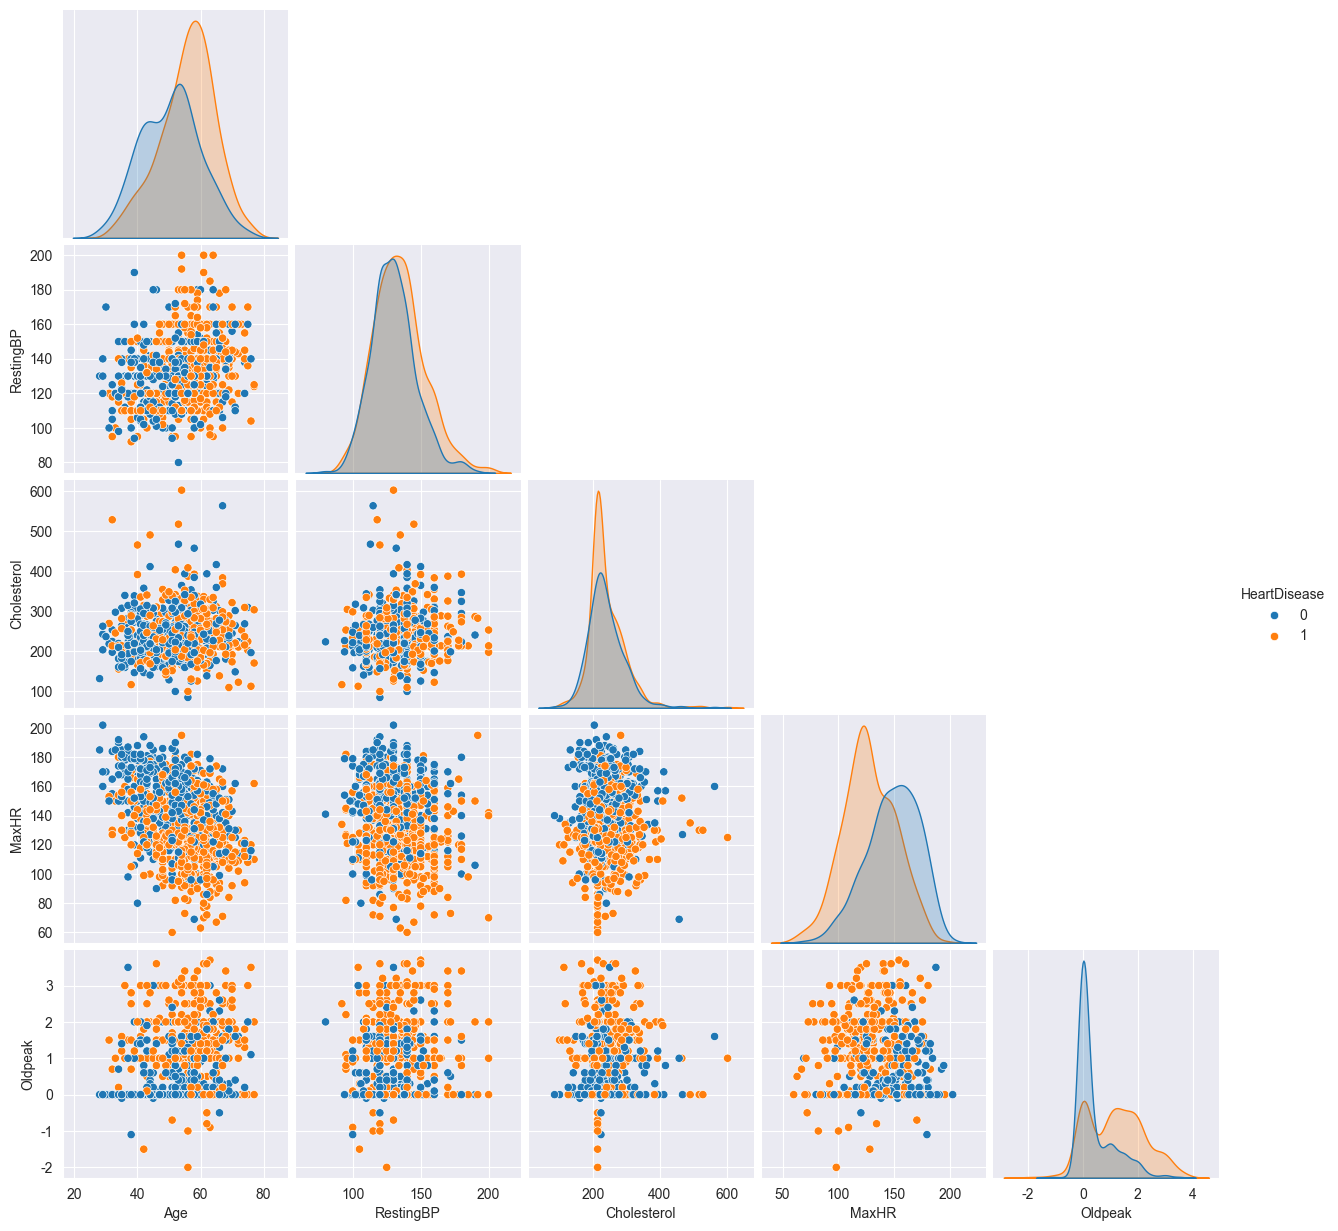

In [30]:
sns.pairplot(data=data[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']], hue='HeartDisease', corner=True)

> comments:

从核密度曲线上看: 
- Age：患病组的年龄分布更偏右；MaxHR：患病组的最大心率分布更偏左；Oldpeak：患病组的ST段压低值更偏右；与之前小提琴图的结论一致
- RestingBP/Cholesterol：`两类人群的分布重叠度高，单特征区分度弱。`

从散点图上看:
- 最凌乱且毫无规律的是Cholesterol vs RestingBP(第二列第三行)，非患病与患病人群的两簇点就是毫无规律地"揉"在一起了。
- 基本上其它组别都可以找到一条`直线作为决策边界大致地将患病人群和非患病人群分开。`
- Age vs MaxHR(第4行第1列)：年龄与最大心率呈负相关；`且患病组的点更集中在高龄 + 低心率区域。`
- Oldpeak vs MaxHR(第5行第4列)：Oldpeak 与 MaxHR 呈负相关；`患病组的点集中在Oldpeak 高 + MaxHR 低区域`，非患病组集中在 “Oldpeak 低 + MaxHR 高” 区域，两类人群几乎无重叠。

- 综合来看: 后续可以先试用'Age', 'MaxHR', 'Oldpeak'这三个特征进行建模看看模型的效果。

### 离散型特征 vs 标签

In [31]:
data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0


In [32]:
col_cate = [col for col in data.columns if data[col].dtype == 'O'] + ['FastingBS']
col_cate

['Sex',
 'ChestPainType',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope',
 'FastingBS']

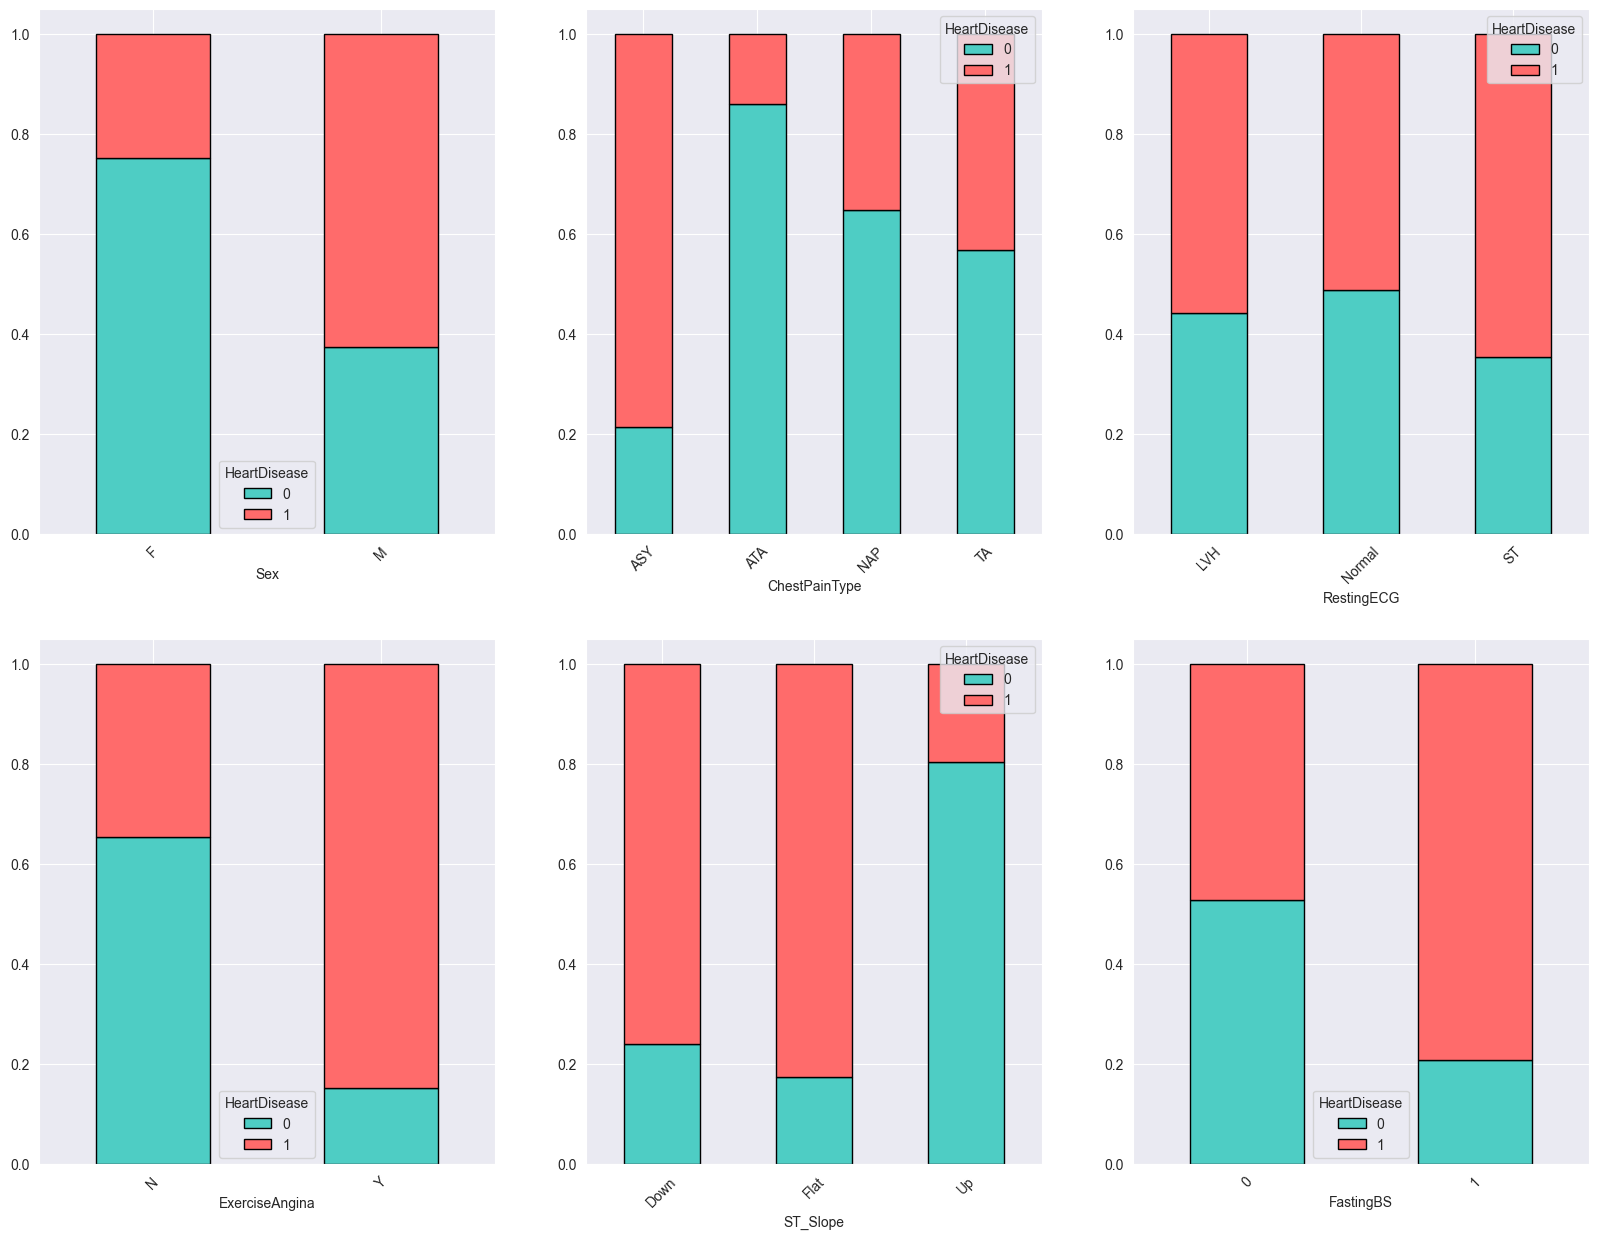

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()
for i, ele in enumerate(col_cate):
    cross_tab = pd.crosstab(
    data[ele],
    data['HeartDisease'],   
    normalize='index',    
    margins=True        
)
    plot_data = cross_tab.drop(index='All')
    plot_data.plot(kind='bar', stacked=True, color=['#4ECDC4', '#FF6B6B'], edgecolor='black', ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)


> comments:
- RestingECG这特征中`三个种类的患病人群和非患病人群的占比相差不大(对比其它特征)`，所以我们可以认为`RestingECG这一个特征对标签的影响较少。`
- Sex: `男性`患心脏病的风险`显著高于女性`。
- ChestPainType(胸痛类型): `ASY(无症状型)：患病比例极高；TA/ATA/NAP(有症状性)患者比例反而偏低。`其实这是符合临床经验的。有症状型患者往往会及时就医，病情能被早期干预，因此未患病的人群更高。
- ExerciseAngina(运动性心绞痛): N(无运动心绞痛), 未患病比例高；Y(有运动心绞痛): 患病比例极高；结论：`运动时出现心绞痛是心脏病的强预警信号。`
- ST_Slope(ST段斜率)Down(下降)/Flat(平坦)：患病比例极高(红色占比接近 100%)；Up(上升)：未患病比例高(绿色占比大)；`结论：ST 段斜率下降 / 平坦是心脏病的典型表现，上升则是健康信号。`
- FastingBS(空腹血糖): 0(正常)：未患病比例高；1(升高)：患病比例高(红色占比大)；`结论：空腹血糖升高会增加心脏病风险。`

In [34]:
# data.to_csv('heart_test.csv')

## 模型的初步建立

In [35]:
data_with_one_hot.head(3)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True


In [36]:
data_with_one_hot.shape

(901, 21)

In [37]:
# data_with_one_hot.columns

In [38]:
feature_names = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY','ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA','RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST','ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down','ST_Slope_Flat', 'ST_Slope_Up']
# feature_names = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak','Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP','ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST','ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
X = data_with_one_hot[feature_names]
y = data_with_one_hot.HeartDisease 

In [39]:
X_train, X_test, y_trian, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [40]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_trian)
pre_y_train_lr = model_lr.predict(X_train)
pre_y_test_lr = model_lr.predict(X_test)
# print(f'逻辑回归在训练集上的准确率: {accuracy_score(pre_y_train_lr, y_trian)}')
print(f'逻辑回归在测试集上的准确率: {accuracy_score(pre_y_test_lr, y_test)}')
print(f'逻辑回归在测试集上的召回率: {recall_score(pre_y_test_lr, y_test)}')
print(f'逻辑回归在测试集上的AUC: {roc_auc_score(pre_y_test_lr, y_test)}')

逻辑回归在测试集上的准确率: 0.850828729281768
逻辑回归在测试集上的召回率: 0.8446601941747572
逻辑回归在测试集上的AUC: 0.8518172765745582


> comments:
- 模型在测试集和训练集上的`表现都不错`，并且在训练集和测试集上的`表现相差不大`。

In [41]:
model_tree = DecisionTreeClassifier(random_state=123)
model_tree.fit(X_train, y_trian)
pre_y_train_tree = model_tree.predict(X_train)
pre_y_test_tree= model_tree.predict(X_test)
# print(f'决策树在训练集上的准确率: {accuracy_score(pre_y_train_tree, y_trian)}')
print(f'决策树在测试集上的准确率: {accuracy_score(pre_y_test_tree, y_test)}')
print(f'决策树在测试集上的召回率: {recall_score(pre_y_test_tree, y_test)}')
print(f'决策树在测试集上的AUC: {roc_auc_score(pre_y_test_tree, y_test)}')

决策树在测试集上的准确率: 0.7790055248618785
决策树在测试集上的召回率: 0.79
决策树在测试集上的AUC: 0.7777160493827162


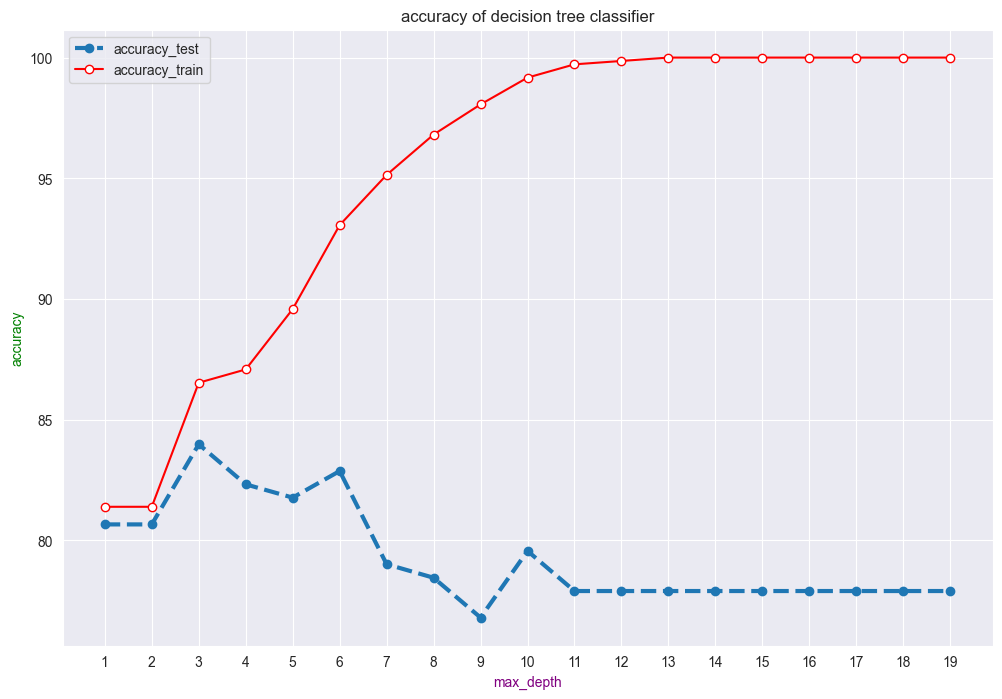

In [42]:
k_plot=[]
t_plot=[]
for k in range(1,20,1):
     dt=DecisionTreeClassifier(max_depth=k,random_state=123)
     dt.fit(X_train,y_trian)
     predict=dt.predict(X_test)
     accuracy_test=round(dt.score(X_test,y_test)*100,2)
     accuracy_train=round(dt.score(X_train,y_trian)*100,2)
     k_plot.append(accuracy_test)
     t_plot.append(accuracy_train)
fig,axes=plt.subplots(1,1,figsize=(12,8))
axes.set_xticks(range(1,20,1))
plt.title("accuracy of decision tree classifier")
plt.xlabel("max_depth", color = "purple")
plt.ylabel("accuracy", color = "green")
k=range(1,20,1)
plt.plot(k,k_plot,linewidth = 3.0, linestyle = '--',marker = "o")
plt.plot(k,t_plot,'r',marker = "o",markerfacecolor = 'white')
plt.legend(['accuracy_test','accuracy_train'])

In [43]:
model_tree = DecisionTreeClassifier(random_state=123, max_depth=3)
model_tree.fit(X_train, y_trian)
pre_y_train_tree = model_tree.predict(X_train)
pre_y_test_tree= model_tree.predict(X_test)
# print(f'决策树在训练集上的准确率: {accuracy_score(pre_y_train_tree, y_trian)}')
print(f'决策树在测试集上的准确率: {accuracy_score(pre_y_test_tree, y_test)}')
print(f'决策树在测试集上的召回率: {recall_score(pre_y_test_tree, y_test)}')
print(f'决策树的测试集上的AUC: {roc_auc_score(pre_y_test_tree, y_test)}')

决策树在测试集上的准确率: 0.8397790055248618
决策树在测试集上的召回率: 0.8415841584158416
决策树的测试集上的AUC: 0.8395420792079208


> comments:
- 可以看到: 决策树在深度为3的时候效果最好(acc最高、模型简单、计算成本较低)。但是有轻微的过拟合现象。

In [44]:
print(classification_report(pre_y_test_tree, y_test))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82        80
           1       0.87      0.84      0.85       101

    accuracy                           0.84       181
   macro avg       0.84      0.84      0.84       181
weighted avg       0.84      0.84      0.84       181



> comments:
- 在训练集上的效果很好，但是在测试集上效果较差，模型在`训练集和测试集上的表现相差很大，属于严重过拟合现象`。

## 模型的修正与调优

##### 由上面的EDA可知: 
- 连续型变量: `RestingBP、Cholesterol`与标签的相关性不大。
- 离散型变量: `RestinECG`与标签的相关性不大。

In [45]:
data['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

### 逻辑回归模型优化

In [46]:
from sklearn.feature_selection import RFECV
selector_lr = RFECV(model_lr, step=1, cv=10, min_features_to_select=1, scoring='recall').fit(X_train, y_trian)

In [47]:
feature_selection_result_lr = pd.DataFrame({
    "feature_name": feature_names,
    "selected": selector_lr.support_,
    "feature_rank": selector_lr.ranking_  
})
feature_selection_result_lr.sort_values(by='feature_rank').head(1)

,feature_name,selected,feature_rank
3,FastingBS,True,1


In [48]:
print(f"最优特征数量：{selector_lr.n_features_}")
selected_features = feature_selection_result_lr[feature_selection_result_lr["selected"]]["feature_name"].tolist()
print('保留的特征名: ', selected_features)

最优特征数量：6
保留的特征名:  ['FastingBS', 'Sex_M', 'ChestPainType_ASY', 'ExerciseAngina_N', 'ST_Slope_Flat', 'ST_Slope_Up']


> comments:
- RFECV确实删除了前面提到的RestingBP、Cholesterol、RestingECG这三个特征，并且结合排名特征的重要性排名，<mark>这三个特征的排名均在比较靠后的位置，这也证明了前面EDA的合理性与可靠性</mark>。

In [49]:
X_train_lr_selected = X_train[selected_features]
X_test_lr_selected = X_test[selected_features]
model_lr_select = model_lr.fit(X_train_lr_selected, y_trian)
pre_y_lr_select = model_lr_select.predict(X_test_lr_selected)
print(f'逻辑回归在测试集上的准确率: {accuracy_score(pre_y_lr_select, y_test)}')
print(f'逻辑回归在测试集上的召回率: {recall_score(pre_y_lr_select, y_test)}')
print(f'逻辑回归在测试集上的AUC: {roc_auc_score(pre_y_lr_select, y_test)}')

逻辑回归在测试集上的准确率: 0.8674033149171271
逻辑回归在测试集上的召回率: 0.8363636363636363
逻辑回归在测试集上的AUC: 0.8759282970550577


> comments:
- `删除了部分特征后，模型在测试集的准确率有所提高。`

In [50]:
param_grid_lr = [
        {
            'penalty': ['l1'], 
            'solver': ['liblinear'],  
            'C': [0.001, 0.01, 0.1, 1, 10, 100],  
            'max_iter': [200, 500],  
            'class_weight': [None, 'balanced'],
            'tol': [1e-4],  
            'random_state': [42] 
        },
        {
            'penalty': ['l2'],
            'solver': ['liblinear', 'lbfgs'],
            'C': [0.01, 0.1, 1, 10, 100],
            'max_iter': [200],
            'class_weight': [None, 'balanced'],
            'tol': [1e-4]
        }
    ]

In [51]:
grid_search_lr = GridSearchCV(model_lr_select, cv=10, scoring='recall', param_grid=param_grid_lr, n_jobs=-1)
grid_search_lr.fit(X_train_lr_selected, y_trian)

GridSearchCV(cv=10, estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'],
                          'max_iter': [200, 500], 'penalty': ['l1'],
                          'random_state': [42], 'solver': ['liblinear'],
                          'tol': [0.0001]},
                         {'C': [0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'], 'max_iter': [200],
                          'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs'],
                          'tol': [0.0001]}],
             scoring='recall')

In [52]:
# print(f'最优参数组合: {grid_search_lr.best_params_}')

In [53]:
model_lr_pro = grid_search_lr.best_estimator_
pre_y_train_lr_pro = model_lr_pro.predict(X_train_lr_selected)
pre_y_test_lr_pro = model_lr_pro.predict(X_test_lr_selected)
# print(f'逻辑回归在训练集上的准确率: {accuracy_score(pre_y_train_lr_pro, y_trian)}')
print(f'逻辑回归在测试集上的准确率: {accuracy_score(pre_y_test_lr_pro, y_test)}')
print(f'逻辑回归在测试集上的召回率: {recall_score(pre_y_test_lr_pro, y_test)}')
print(f'AUC值: {roc_auc_score(pre_y_test_lr_pro, y_test)}')

逻辑回归在测试集上的准确率: 0.8729281767955801
逻辑回归在测试集上的召回率: 0.8378378378378378
AUC值: 0.8832046332046332


> comments:
- 经过网格搜索调整模型超参数以后，`模型的效果进一步提高`。
- 在测试集上的`准确率和AUC分别为: 0.8729281767955801，0.8832046332046332`在实际的医疗数据已经很不错的模型效果了。

### 决策树模型的优化

In [54]:
selector_tree = RFECV(model_tree, cv=10, scoring='recall', step=3, min_features_to_select=1, n_jobs=-1).fit(X_train, y_trian)

In [55]:
feature_selection_result_tree = pd.DataFrame({
    "feature_name": feature_names,
    "selected": selector_tree.support_,
    "feature_rank": selector_tree.ranking_  
})
# feature_selection_result_tree.sort_values(by='feature_rank')

In [56]:
print(f"最优特征数量：{selector_tree.n_features_}")
selected_features_tree = feature_selection_result_tree[feature_selection_result_tree["selected"]]["feature_name"].tolist()
print('保留的特征名: ', selected_features_tree)

最优特征数量：5
保留的特征名:  ['Oldpeak', 'Sex_M', 'ChestPainType_ASY', 'ExerciseAngina_Y', 'ST_Slope_Up']


> comments:
- 可以看到: RFECV确实也删除了前面提到的RestingBP、Cholesterol、RestingECG这三个特征，<mark>同样证明了前面EDA的合理性与可靠性</mark>。

In [57]:
X_train_tree_select = X_train[selected_features_tree]
X_test_tree_select = X_test[selected_features_tree]

In [58]:
model_tree_select = DecisionTreeClassifier(max_depth=3, random_state=123)  
model_tree_select.fit(X_train_tree_select, y_trian)
pre_y_tree_select_test = model_tree_select.predict(X_test_tree_select)
pre_y_tree_select_train = model_tree_select.predict(X_train_tree_select)
print(f'决策树在训练集上的准确率: {accuracy_score(pre_y_tree_select_train, y_trian)}')
print(f'决策树在测试集上的准确率: {accuracy_score(pre_y_tree_select_test, y_test)}')
print(f'决策树在测试集上的召回率: {recall_score(pre_y_tree_select_test, y_test)}')
print(f'决策树在测试集上的AUC: {roc_auc_score(pre_y_tree_select_test, y_test)}')

决策树在训练集上的准确率: 0.8652777777777778
决策树在测试集上的准确率: 0.8397790055248618
决策树在测试集上的召回率: 0.8415841584158416
决策树在测试集上的AUC: 0.8395420792079208


> comments:
- 经过特征数量的调整，模型的性能没有发生改变，猜测可能原因是模型在第一次训练时已经成功识别出了真正有用的特征。

## 模型的解释与评估

### 逻辑回归与决策树模型性能对比表

| 模型类型       | 训练阶段               | 测试集准确率         | 测试集召回率         | 测试集AUC值          |
|----------------|------------------------|----------------------|----------------------|----------------------|
| 逻辑回归       | 初次训练               | 0.850828729281768    | `0.8446601941747572`   | 0.8518172765745582   |
|        | 经过RFECV特征选择后    | 0.8674033149171271   | 0.8363636363636363   | 0.8759282970550577   |
|        | 进行网格搜索后         | `0.8729281767955801`   | 0.8378378378378378   |` 0.8832046332046332 `  |
| 决策树         | 初次训练               | 0.7790055248618785   | 0.79                 | 0.7777160493827162   |
|          | 调节max_depth参数后    | `0.8397790055248618`   | `0.8415841584158416`   | `0.8395420792079208`   |
|          | 进行RFECV后            |    | 同上 |   |

> 横向对比两个调优后的模型，`逻辑回归在关键指标上略胜一筹`：

- 准确率优势：逻辑回归（0.8729）高于决策树（0.8398）

- 区分能力更强：逻辑回归的AUC值达到0.8832，明显高于决策树的0.8395

- 召回率相当：两者召回率相近，决策树仅略高0.38%

- 在医学应用场景中，AUC值是评估模型区分能力的重要指标，0.88以上的AUC通常被认为具有良好的预测性能。逻辑回归在这一核心指标上的优势，使其更适合用于临床风险评估或辅助诊断。

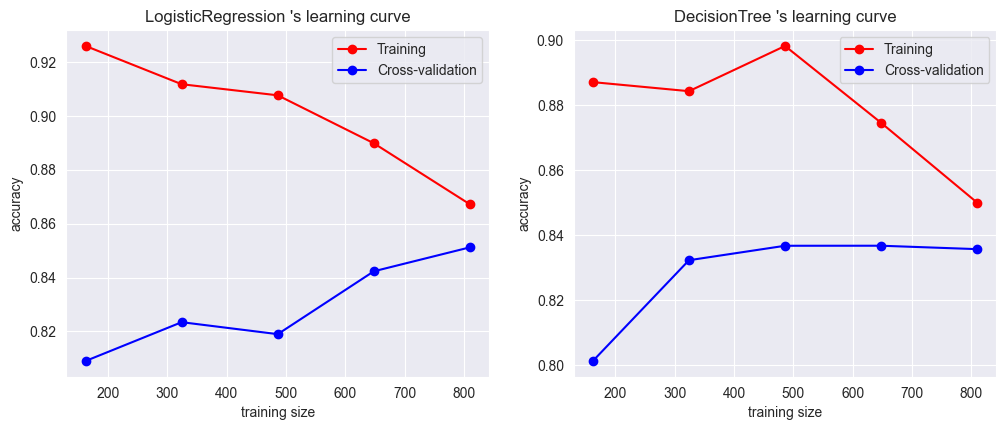

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
train_sizes_lr, train_loss_lr, test_loss_lr = learning_curve(
    model_lr_pro, X[selected_features], y, cv=10, scoring='accuracy',
    train_sizes=[0.20, 0.4, 0.6, 0.8, 1]
)
train_loss_lr = np.mean(train_loss_lr, axis=1)
test_loss_lr = np.mean(test_loss_lr, axis=1)
train_sizes_tree, train_loss_tree, test_loss_tree = learning_curve(
    model_lr_pro, X[selected_features_tree], y, cv=10, scoring='accuracy',
    train_sizes=[0.20, 0.4, 0.6, 0.8, 1]
)
train_loss_tree = np.mean(train_loss_tree, axis=1)
test_loss_tree = np.mean(test_loss_tree, axis=1)
axes[0].plot(train_sizes_lr, train_loss_lr, 'o-', color='r', label="Training")
axes[0].plot(train_sizes_lr, test_loss_lr, 'o-', color='b', label='Cross-validation')
axes[0].set_ylabel('accuracy')
axes[0].set_xlabel('training size')
axes[0].set_title(f'LogisticRegression \'s learning curve')
axes[0].legend()

axes[1].plot(train_sizes_tree, train_loss_tree, 'o-', color='r', label="Training")
axes[1].plot(train_sizes_tree, test_loss_tree, 'o-', color='b', label='Cross-validation')
axes[1].set_ylabel('accuracy')
axes[1].set_xlabel('training size')
axes[1].set_title(f'DecisionTree \'s learning curve')
axes[1].legend()

> comments:
- 两个模型随着训练数据的增加训练集和交叉验证的准确率曲线都有`收敛的趋势，这是一个很好的现象，说明模型的泛化能力随机数据量的增加而持续增加。两个模型整体效果都不错`
- 逻辑回归：学习曲线显示其`泛化能力随样本量提升持续增强`，过拟合问题可通过数据缓解，稳定性强。
- 决策树：学习曲线显示其`泛化能力易触顶`，且始终存在明显过拟合，`稳定性弱于逻辑回归`。
- <mark>再一次说明了逻辑回归的性能要优于决策树</mark>。

### 模型解释

#### 逻辑回归

In [60]:
log_reg = sm.Logit(y_trian,sm.add_constant(X_train_lr_selected.astype(int))).fit()
log_reg.summary()

Optimization terminated successfully.
         Current function value: 0.349289
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           HeartDisease   No. Observations:                  720
Model:                          Logit   Df Residuals:                      713
Method:                           MLE   Df Model:                            6
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.4928
Time:                        20:41:53   Log-Likelihood:                -251.49
converged:                       True   LL-Null:                       -495.85
Covariance Type:            nonrobust   LLR p-value:                2.257e-102
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.3073      0.552     -2.367      0.018      -2.390      -0.225
FastingBS             1.3699      0.292      4.684      0.000       0.797       1.943
Sex_M                 1.5202      0.303      5.014      0.000       0.926       2.114
ChestPainType_ASY     1.8250      0.239      7.649      0.000       1.357       2.293
ExerciseAngina_N     -0.9986      0.261     -3.821      0.000      -1.511      -0.486
ST_Slope_Flat         0.9081      0.464      1.957      0.050      -0.002       1.818
ST_Slope_Up          -1.6441      0.470     -3.502      0.000      -2.564      -0.724
=====================================================================================
"""

逻辑回归的模型为：
$$\log\left( \frac{p}{1-p} \right) = -1.3073 + 1.3699X_1 + 1.5202X_2 + 1.8250X_3 - 0.9986X_4 + 0.9081X_5 - 1.6441X_6$$


| 特征变量 | 含义 | 变量取值说明 |
|----------|----------|--------------|
| $X_1$（FastingBS） | 空腹血糖 | 数值型（单位：mmol/L） |
| $X_2$（Sex_M） | 性别 | 1=男性，0=女性 |
| $X_3$（ChestPainType_ASY） | 胸痛类型 | 1=无症状型，0=其他类型 |
| $X_4$（ExerciseAngina_N） | 运动性心绞痛 | 1=无，0=有 |
| $X_5$（ST_Slope_Flat） | ST段斜率 | 1=平坦型，0=其他类型 |
| $X_6$（ST_Slope_Up） | ST段斜率 | 1=上升型，0=其他类型 |

- 空腹血糖（FastingBS）：$e^{1.3699}≈3.99$。
  - 含义：其余条件相同时，**空腹血糖每增加1个单位，患病的几率是原来的约3.99倍**，说明空腹血糖升高是目标事件的高风险因素。

- Sex_M指数化系数（Odds Ratio）：$e^{1.5202}≈4.57$。
  - 含义：其余条件相同时，**男性患病的几率是女性的约4.57倍**，男性属于目标事件的高风险群体。

- 胸痛类型（ChestPainType_ASY）：$e^{1.8250}≈6.21$。
  - 含义：其余条件相同时，**无症状型胸痛患者患病的几率是其他胸痛类型患者的约6.21倍**，无症状型胸痛是核心高风险特征。

- 运动性心绞痛（ExerciseAngina_N）：$e^{-0.9986}≈0.37$。
  - 含义：其余条件相同时，**无运动性心绞痛者患病的几率是有运动性心绞痛者的约0.37倍**，有运动性心绞痛是高风险特征。

- ST段斜率（ST_Slope_Flat）：$e^{0.9081}≈2.48$。
  - 含义：其余条件相同时，**ST段为平坦型的患者患病的几率是其他类型者的约2.48倍**，平坦型ST段是潜在风险特征。
- ST段斜率（ST_Slope_U）：$e^{-1.6441}≈0.19$。
  - 含义：其余条件相同时，**ST段为上升型的患者患病的几率是其他类型者的约0.19倍**，上升型ST段是低风险保护特征。

#### 决策树

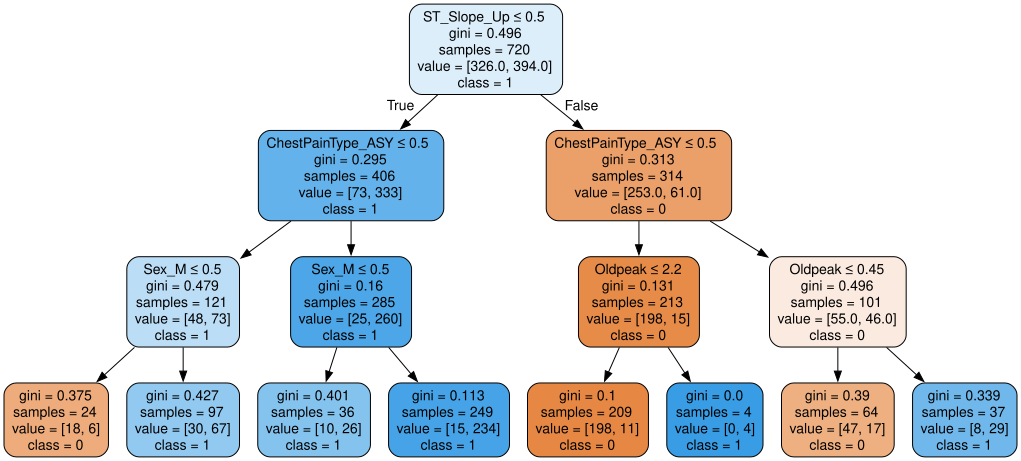

In [61]:
class_names = [str(c) for c in model_tree_select.classes_]

dot_data = export_graphviz(
    model_tree_select,
    out_file=None,
    feature_names=selected_features_tree,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph

> comments:
- 这个决策树先以 “ST_Slope_Up 是否≤0.5” 拆分样本：若满足则进入分支，通过 “ChestPainType_ASY”“Sex_M” 进一步划分，多数样本被判定为 class 1；若不满足则进入另一分支，通过 “ChestPainType_ASY”“Oldpeak” 细分，多数样本被判定为 class 0。整个过程通过三层特征逐步分裂，完成类别判定。

# ====================至此====================
已完成期末作业所有内容.......

但是出于好奇，想看看其它更高级的模型在这个数据集的表现

于是开始了下面的尝试......

In [62]:
xgb = XGBClassifier()
xgb.fit(X_train, y_trian)
pre_y_test = xgb.predict(X_test)
pre_y_train = xgb.predict(X_train)
print(f'XGBoost在训练集上的准确率: {accuracy_score(pre_y_train, y_trian)}')
print(f'XGBoost在测试集上的准确率: {accuracy_score(pre_y_test, y_test)}')
print(f'XGBoost在测试集上的ACU: {roc_auc_score(pre_y_test, y_test)}')

XGBoost在训练集上的准确率: 1.0
XGBoost在测试集上的准确率: 0.8784530386740331
XGBoost在测试集上的ACU: 0.884830035514967


> comments:
- 虽然说是过拟合，但是也已经战胜了经过调参后的逻辑回归了

In [64]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

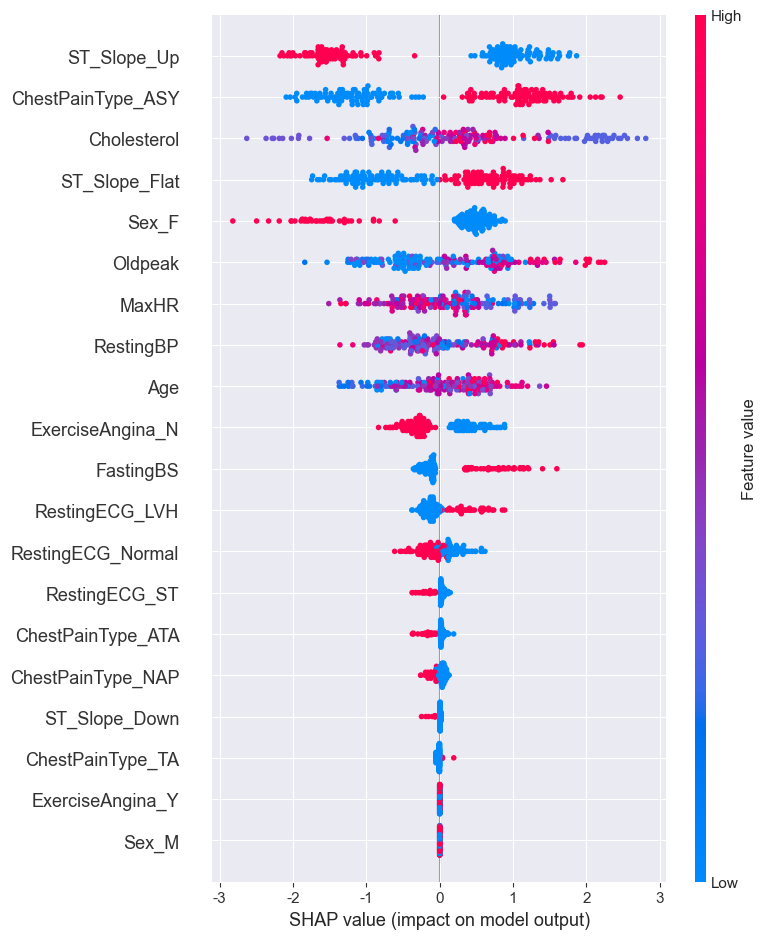

In [66]:
shap.summary_plot(shap_values, X_test)

> comments:
- 这个模型主要通过`心电图ST段斜率、胸痛类型、性别`等核心特征判断心脏病风险：
- ST 段斜率为 `“Up”、非 ASY 型胸痛、女性`，会降低患病风险；
- ST 段斜率为 `“Flat”、ASY 型胸痛、男性`，会升高患病风险。

In [66]:
xgb_param_dist = {
    'max_depth': stats.randint(3, 8),          
    'min_child_weight': stats.randint(1, 6),  
    'gamma': stats.uniform(0, 0.3),          
    'learning_rate': stats.loguniform(0.01, 0.2), 
    'n_estimators': stats.randint(100, 301),   
    'subsample': stats.uniform(0.8, 0.2),      
    'colsample_bytree': stats.uniform(0.8, 0.2),
    'reg_alpha': stats.uniform(0, 1),          
    'reg_lambda': stats.uniform(1, 4),  
    'objective': ['binary:logistic'],
    'eval_metric': ['auc'],
    'booster': ['gbtree'],
}

In [67]:
os.cpu_count()

16

In [97]:
xgb_acc = []
xgb_auc = []
for i in range(30):
        random_search_xgb = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=xgb_param_dist,
        n_iter=500,                
        cv=10,                     
        scoring='accuracy',         
        n_jobs=-1)
        random_search_xgb.fit(X_train, y_trian)
        xgb = random_search_xgb.best_estimator_
        pre_y = xgb.predict(X_test)
        xgb_acc.append(accuracy_score(pre_y, y_test))
        xgb_auc.append(roc_auc_score(pre_y, y_test))

In [98]:
print(f'随机搜索平均准确率: {np.mean(xgb_acc)}')
print(f'随机搜索平均AUC: {np.mean(xgb_auc)}')

随机搜索平均准确率: 0.8854511970534072
随机搜索平均AUC: 0.8911074859665521


> comments:
- 模型的平均调优性能比原模型的性能要高，证明调优还是有意义的。
- `准确率为88.5%、AUC为89.1%比逻辑回归和决策树效果都更优`。 

In [68]:
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_trian)

[LightGBM] [Info] Number of positive: 394, number of negative: 326
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 720, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.547222 -> initscore=0.189454
[LightGBM] [Info] Start training from score 0.189454
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

LGBMClassifier()

In [80]:
pre_y = lgbm.predict(X_test)
print(f'LightGBM在测试集上的准确率: {accuracy_score(pre_y, y_test)}')
print(f'LightGBM在测试集上的AUC: {roc_auc_score(pre_y, y_test)}')

LightGBM在测试集上的准确率: 0.8895027624309392
LightGBM在测试集上的AUC: 0.8963089802130897


In [69]:
catboost = CatBoostClassifier(
    verbose=1001
)
catboost.fit(X_train, y_trian)

Learning rate set to 0.008954
0:	learn: 0.6854362	total: 153ms	remaining: 2m 32s
999:	learn: 0.1141162	total: 2.14s	remaining: 0us


In [70]:
pre_y = catboost.predict(X_test)
print(f'Catboost在测试集上的准确率: {accuracy_score(pre_y, y_test)}')
print(f'Catboost在测试集上的AUC: {roc_auc_score(pre_y, y_test)}')

Catboost在测试集上的准确率: 0.8895027624309392
Catboost在测试集上的AUC: 0.8963089802130897


> comments:
- 当前最优的模型是LightGBM和Catboost，其准确率(89%)和AUC(90%)值都是一样的。
- 并且训练的比较好的模型`逻辑回归`，准确率和AUC值`也与上面模型差距不大`。
- 所以，猜测要是再想提高模型的性能就需要从特征工程的角度进行优化了。